# Proyek Analisis Data: Bike-sharing-dataset
- **Nama:** Clarisya Adeline
- **Email:** cdcc011d6x1678@student.devacademy.id
- **ID Dicoding:** cdcc011d6x1678

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".



---


Dataset yang digunakan adalah **Bike Sharing Dataset** dari Capital Bikeshare system, Washington D.C., USA (2011–2012). Dataset ini mencatat jumlah peminjaman sepeda per jam dan per hari beserta kondisi cuaca dan musim.

Berdasarkan pemahaman terhadap dataset, berikut dua pertanyaan bisnis yang memenuhi kerangka **SMART Question**:

### Pertanyaan 1
> **"Bagaimana pengaruh kondisi cuaca (weathersit) dan suhu (temp) terhadap rata-rata jumlah total peminjaman sepeda harian (cnt) di Capital Bikeshare Washington D.C. selama periode 2011–2012, dan kategori cuaca mana yang menghasilkan penurunan peminjaman paling signifikan?"**

Keterangan SMART:
- **Specific**: Fokus pada variabel `weathersit` dan `temp` terhadap `cnt` harian.
- **Measurable**: Diukur dengan rata-rata `cnt` per kategori cuaca dan korelasi numerik.
- **Action-Oriented**: Hasil dapat digunakan untuk perencanaan ketersediaan armada sepeda berdasarkan prakiraan cuaca.
- **Relevant**: Cuaca adalah faktor eksternal utama yang memengaruhi keputusan seseorang untuk bersepeda.
- **Time-bound**: Dibatasi pada data tahun 2011–2012.

### Pertanyaan 2
> **"Pada jam berapa saja dalam sehari terjadi puncak peminjaman sepeda (peak hours) dan bagaimana pola tersebut berbeda antara hari kerja (workingday) dan hari libur selama periode 2011–2012, sehingga dapat ditentukan strategi distribusi sepeda yang optimal?"**

Keterangan SMART:
- **Specific**: Fokus pada distribusi `cnt` per jam (`hr`) yang dibedakan oleh `workingday`.
- **Measurable**: Diukur dengan rata-rata `cnt` per jam untuk setiap kelompok hari.
- **Action-Oriented**: Membantu operator menentukan waktu redistribusi armada sepeda.
- **Relevant**: Pola jam penggunaan langsung berdampak pada ketersediaan sepeda di stasiun.
- **Time-bound**: Dibatasi pada data tahun 2011–2012.


## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

#style settings
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'Dejavu Sans'
sns.set_theme(style='whitegrid', palette = 'muted')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## Data Wrangling

### Gathering Data

Pada tahap ini, kita memuat dua dataset utama:
1. **`day.csv`** — Data agregasi harian (731 baris)
2. **`hour.csv`** — Data agregasi per jam (17.379 baris)

#### Load day.csv

In [ ]:
day_df = pd.read_csv('data/day.csv')
print(f'Shape:{day_df.shape}')
day_df.head()

Shape:(731, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


#### Load hour.csv

In [ ]:
hour_df = pd.read_csv('data/hour.csv')
print(f'Shape:{hour_df.shape}')
hour_df.head()

Shape:(17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset `day.csv` memiliki 731 baris (sesuai 2 tahun: 365 + 366 hari) dan 16 kolom.
- Dataset `hour.csv` memiliki 17.379 baris dan 17 kolom (tambahan kolom `hr`).
- Variabel numerik seperti `temp`, `atemp`, `hum`, dan `windspeed` disimpan dalam bentuk ternormalisasi (0–1).
- Variabel target utama adalah `cnt` (total peminjaman = `casual` + `registered`).

### Assessing Data

Pada tahap ini kita menilai kualitas data dari berbagai aspek: missing values, duplikasi, tipe data, dan outlier.

#### Identifying Missing Values, Data Types, and Descriptive Statistics

In [ ]:
# Assessing Data - day_df
print('=== day_df Info ===')
print(f'Shape: {day_df.shape}')

print('\nMissing Values:')
print(day_df.isnull().sum())

print('\nDuplicated rows:')
print(day_df.duplicated().sum())

print('\nData types:')
print(day_df.dtypes)

print('\nStatistical Summary:')
day_df.describe()

=== day_df Info ===
Shape: (731, 16)

Missing Values:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Duplicated rows:
0

Data types:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

Statistical Summary:


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [ ]:
# Assessing Data - hour_df
print('=== hour_df Info ===')
print(f'Shape: {hour_df.shape}')

print('\nMissing Values:')
print(hour_df.isnull().sum())

print('\nDuplicated rows:')
print(hour_df.duplicated().sum())

print('\nData types:')
print(hour_df.dtypes)

print('\nStatistical Summary:')
hour_df.describe()

=== hour_df Info ===
Shape: (17379, 17)

Missing Values:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Duplicated rows:
0

Data types:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

Statistical Summary:


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


### Identifying Incorrect Data Types

In [ ]:
#Kolom dteday seharusnya bertipe datetime, bukan object
print('Tipe kolom dteday pada day_df:', day_df['dteday'].dtype)
print('Contoh nilai:', day_df['dteday'].head().values)

print('\nTipe kolom dteday pada hour_df:', hour_df['dteday'].dtype)
print('Contoh nilai:', hour_df['dteday'].head().values)

#Kolom kategorikal yang tersimpan sebagai int64
cat_cols = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
print('\nKolom yang seharusnya kategorikal namun bertipe int64:')
print(day_df[cat_cols].dtypes)

Tipe kolom dteday pada day_df: object
Contoh nilai: ['2011-01-01' '2011-01-02' '2011-01-03' '2011-01-04' '2011-01-05']

Tipe kolom dteday pada hour_df: object
Contoh nilai: ['2011-01-01' '2011-01-01' '2011-01-01' '2011-01-01' '2011-01-01']

Kolom yang seharusnya kategorikal namun bertipe int64:
season        int64
yr            int64
mnth          int64
holiday       int64
weekday       int64
workingday    int64
weathersit    int64
dtype: object


### Identifying Outlier

In [ ]:
#Deteksi outlier dengan metode IQR pada kolom numeric
numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

outlier_summary = {}
for col in numeric_cols:
  Q1 = day_df[col].quantile(0.25)
  Q3 = day_df[col].quantile(0.75)
  IQR = Q3 - Q1
  minimum = Q1 - 1.5 * IQR
  maximum = Q3 + 1.5 * IQR
  n_outliers = ((day_df[col] < minimum) | (day_df[col] > maximum)).sum()
  outlier_summary[col] = n_outliers

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Jumlah Outlier'])
print('Jumlah outlier per kolom(day_df):')
print(outlier_df)

Jumlah outlier per kolom(day_df):
            Jumlah Outlier
temp                     0
atemp                    0
hum                      2
windspeed               13
casual                  44
registered               0
cnt                      0


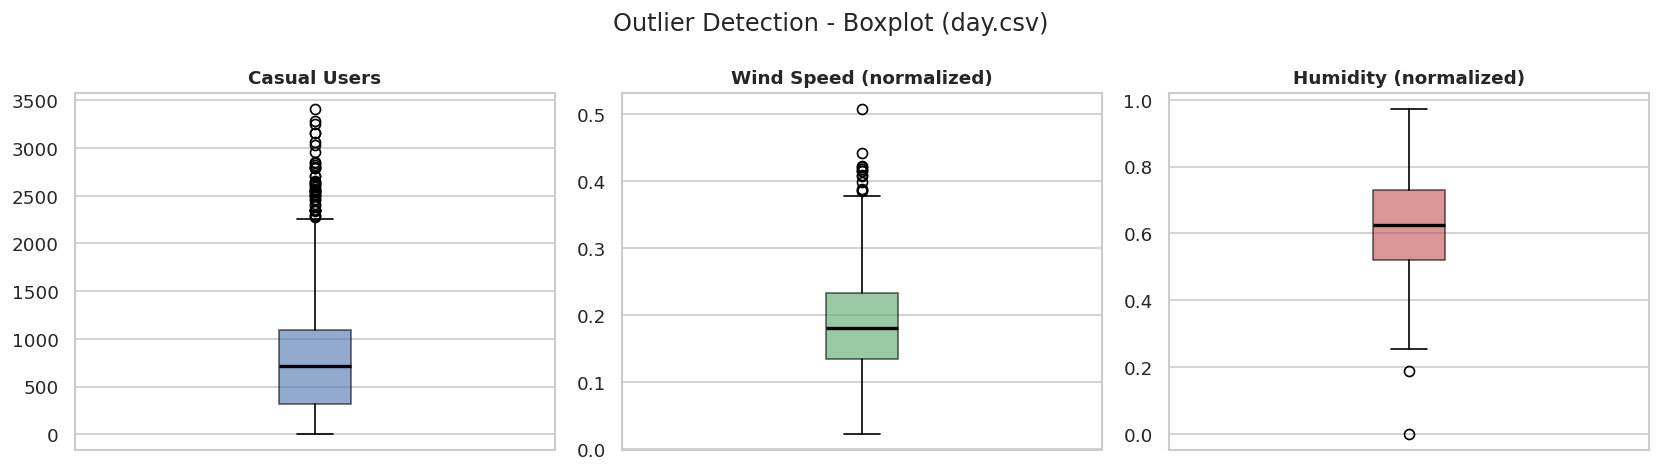

In [ ]:
#Visualisasi Outlier (boxplot)
fig, axes = plt.subplots(1,3, figsize=(14,4))
cols_to_plot = ['casual', 'windspeed', 'hum']
titles = ['Casual Users', 'Wind Speed (normalized)', 'Humidity (normalized)']
colors = ['#4C72B0', '#55A868', '#C44E52']

for ax, col, title, color in zip(axes, cols_to_plot, titles, colors):
  ax.boxplot(day_df[col], patch_artist=True,
             boxprops=dict(facecolor=color, alpha=0.6),
             medianprops=dict(color='black', linewidth=2))
  ax.set_title(title, fontsize = 11, fontweight='bold')
  ax.set_xticks([])

plt.suptitle('Outlier Detection - Boxplot (day.csv)')
plt.tight_layout()
plt.savefig('boxplot_outliers.png', bbox_inches='tight')
plt.show()

### Identifying Invalid and Inconsistent Values

In [ ]:
# Mengecek invalid dan inconsistent values pada day_df

invalid_checks_day = {
    'season_not_1_4': ~day_df['season'].isin([1, 2, 3, 4]),
    'yr_not_0_1': ~day_df['yr'].isin([0, 1]),
    'mnth_not_1_12': ~day_df['mnth'].between(1, 12),
    'holiday_not_0_1': ~day_df['holiday'].isin([0, 1]),
    'weekday_not_0_6': ~day_df['weekday'].between(0, 6),
    'workingday_not_0_1': ~day_df['workingday'].isin([0, 1]),
    'weathersit_not_1_4': ~day_df['weathersit'].isin([1, 2, 3, 4]),
    'temp_outside_0_1': ~day_df['temp'].between(0, 1),
    'atemp_outside_0_1': ~day_df['atemp'].between(0, 1),
    'hum_outside_0_1': ~day_df['hum'].between(0, 1),
    'windspeed_outside_0_1': ~day_df['windspeed'].between(0, 1),
    'negative_counts': (day_df[['casual', 'registered', 'cnt']] < 0).any(axis=1),
    'cnt_not_equal_casual_registered': day_df['cnt'] != day_df['casual'] + day_df['registered']
}

invalid_summary_day = pd.Series({
    name: condition.sum()
    for name, condition in invalid_checks_day.items()
})

print('Invalid/Inconsistent Value Check - day_df:')
print(invalid_summary_day)

Invalid/Inconsistent Value Check - day_df:
season_not_1_4                     0
yr_not_0_1                         0
mnth_not_1_12                      0
holiday_not_0_1                    0
weekday_not_0_6                    0
workingday_not_0_1                 0
weathersit_not_1_4                 0
temp_outside_0_1                   0
atemp_outside_0_1                  0
hum_outside_0_1                    0
windspeed_outside_0_1              0
negative_counts                    0
cnt_not_equal_casual_registered    0
dtype: int64


In [ ]:
# Mengecek invalid dan inconsistent values pada hour_df

invalid_checks_hour = {
    'season_not_1_4': ~hour_df['season'].isin([1, 2, 3, 4]),
    'yr_not_0_1': ~hour_df['yr'].isin([0, 1]),
    'mnth_not_1_12': ~hour_df['mnth'].between(1, 12),
    'hr_not_0_23': ~hour_df['hr'].between(0, 23),
    'holiday_not_0_1': ~hour_df['holiday'].isin([0, 1]),
    'weekday_not_0_6': ~hour_df['weekday'].between(0, 6),
    'workingday_not_0_1': ~hour_df['workingday'].isin([0, 1]),
    'weathersit_not_1_4': ~hour_df['weathersit'].isin([1, 2, 3, 4]),
    'temp_outside_0_1': ~hour_df['temp'].between(0, 1),
    'atemp_outside_0_1': ~hour_df['atemp'].between(0, 1),
    'hum_outside_0_1': ~hour_df['hum'].between(0, 1),
    'windspeed_outside_0_1': ~hour_df['windspeed'].between(0, 1),
    'negative_counts': (hour_df[['casual', 'registered', 'cnt']] < 0).any(axis=1),
    'cnt_not_equal_casual_registered': hour_df['cnt'] != hour_df['casual'] + hour_df['registered']
}

invalid_summary_hour = pd.Series({
    name: condition.sum()
    for name, condition in invalid_checks_hour.items()
})

print('Invalid/Inconsistent Value Check - hour_df:')
print(invalid_summary_hour)

Invalid/Inconsistent Value Check - hour_df:
season_not_1_4                     0
yr_not_0_1                         0
mnth_not_1_12                      0
hr_not_0_23                        0
holiday_not_0_1                    0
weekday_not_0_6                    0
workingday_not_0_1                 0
weathersit_not_1_4                 0
temp_outside_0_1                   0
atemp_outside_0_1                  0
hum_outside_0_1                    0
windspeed_outside_0_1              0
negative_counts                    0
cnt_not_equal_casual_registered    0
dtype: int64


**Steps to Take:**
- Problem 1 - Incorrect Data Types: kolom `dteday` perlu dikonversi ke tipe `datetime`. Kolom-kolom kategorikan (`season`, `weathersit`, dll.) perlu dipetakan ke nama yang lebih deskriptif agar analisis lebih mudah dibaca.
- Problem 2 - Outliers pada `casual` dan `windspeed`: Outlier tidak akan dihapus karena merupakan kejadian nyata (misalnya hari dengan angin kencang atau event khusus). Namun perlu didokumentasikan dan dipertimbangkan saat interpretasi


**Insight:**
- Dataset tidak memiliki missing value dan duplikasi, sehingga kualitas data awal cukup baik.
- Kolom `dteday` perlu dikonversi menjadi `datetime`, sedangkan beberapa kolom numerik seperti `season`, `weekday`, `workingday`, dan `weathersit` perlu diperlakukan sebagai kategorikal.
- Outlier ditemukan terutama pada `casual` dan `windspeed`, tetapi tidak dihapus karena masih dapat merepresentasikan kondisi nyata, seperti lonjakan pengguna pada hari tertentu atau kondisi cuaca ekstrem.
- Kolom `cnt` tidak memiliki outlier pada `day_df`, sehingga jumlah total peminjaman harian relatif stabil untuk dianalisis.
- Tidak ditemukan invalid dan inconsistent values

### Cleaning Data

#### Fixing Data Types - Konversi dteday ke datetime

In [ ]:
#Konversi dteday ke datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

print('Tipe dteday setelah konversi (day_df):', day_df['dteday'].dtype)
print('Tipe dteday setelah konversi (hour_df):', hour_df['dteday'].dtype)

Tipe dteday setelah konversi (day_df): datetime64[ns]
Tipe dteday setelah konversi (hour_df): datetime64[ns]


#### Fixing Categorical Labels - Pemetaan Nilai Numerik ke Label Deskriptif

In [ ]:
# Mapping dictionaries
season_map   = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map  = {1: 'Clear', 2: 'Mist/Cloudy', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'}
weekday_map  = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}
month_map    = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
                7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
year_map     = {0: 2011, 1: 2012}
workingday_map = {0: 'Holiday/Weekend', 1: 'Working Day'}

# Apply mapping to day_df
day_df['season_label']      = day_df['season'].map(season_map)
day_df['weather_label']     = day_df['weathersit'].map(weather_map)
day_df['weekday_label']     = day_df['weekday'].map(weekday_map)
day_df['month_label']       = day_df['mnth'].map(month_map)
day_df['year_actual']       = day_df['yr'].map(year_map)
day_df['workingday_label']  = day_df['workingday'].map(workingday_map)

# Denormalize day_df
day_df['temp_celsius']      = day_df['temp'] * 41
day_df['hum_percent']       = day_df['hum'] * 100
day_df['windspeed_kmh']     = day_df['windspeed'] * 67

# Binning: Usage Category for day_df
day_df['usage_category_day'] = pd.cut(
    day_df['cnt'],
    bins=[0, 2000, 4000, 6000, 9000],
    labels=['Low (0-2K)', 'Medium (2K-4K)', 'High (4K-6K)', 'Very High (6K+)'],
    include_lowest=True
)

print('Cleaning selesai. Kolom baru ditambahkan pada day_df:')
new_cols_day = [
    'season_label', 'weather_label', 'weekday_label', 'month_label',
    'year_actual', 'workingday_label', 'temp_celsius',
    'hum_percent', 'windspeed_kmh', 'usage_category_day'
]

display(day_df[new_cols_day].head().style.hide(axis="index"))


Cleaning selesai. Kolom baru ditambahkan pada day_df:


season_label,weather_label,weekday_label,month_label,year_actual,workingday_label,temp_celsius,hum_percent,windspeed_kmh,usage_category_day
Spring,Mist/Cloudy,Sat,Jan,2011,Holiday/Weekend,14.110847,80.583300,10.749882,Low (0-2K)
Spring,Mist/Cloudy,Sun,Jan,2011,Holiday/Weekend,14.902598,69.608700,16.652113,Low (0-2K)
Spring,Clear,Mon,Jan,2011,Working Day,8.050924,43.727300,16.636703,Low (0-2K)
Spring,Clear,Tue,Jan,2011,Working Day,8.200000,59.043500,10.739832,Low (0-2K)
Spring,Clear,Wed,Jan,2011,Working Day,9.305237,43.695700,12.522300,Low (0-2K)


In [ ]:
# Apply mapping to hour_df
hour_df['season_label']     = hour_df['season'].map(season_map)
hour_df['weather_label']    = hour_df['weathersit'].map(weather_map)
hour_df['weekday_label']    = hour_df['weekday'].map(weekday_map)
hour_df['month_label']      = hour_df['mnth'].map(month_map)
hour_df['year_actual']      = hour_df['yr'].map(year_map)
hour_df['workingday_label'] = hour_df['workingday'].map(workingday_map)

# Denormalize hour_df
hour_df['temp_celsius']     = hour_df['temp'] * 41
hour_df['hum_percent']      = hour_df['hum'] * 100
hour_df['windspeed_kmh']    = hour_df['windspeed'] * 67\

# Binning: Usage Category for hour_df
hour_df['usage_category_hour'] = pd.cut(
    hour_df['cnt'],
    bins=[0, 200, 400, 600, 1000],
    labels=['Low (0-200)', 'Medium (200-400)', 'High (400-600)', 'Very High (600+)'],
    include_lowest=True
)

print('Cleaning selesai. Kolom baru ditambahkan pada hour_df:')
new_cols_hour = [
    'season_label', 'weather_label', 'weekday_label', 'month_label',
    'year_actual', 'workingday_label', 'temp_celsius',
    'hum_percent', 'windspeed_kmh', 'usage_category_hour'
]

display(hour_df[new_cols_hour].head())

Cleaning selesai. Kolom baru ditambahkan pada hour_df:


,season_label,weather_label,weekday_label,month_label,year_actual,workingday_label,temp_celsius,hum_percent,windspeed_kmh,usage_category_hour
0,Spring,Clear,Sat,Jan,2011,Holiday/Weekend,9.84,81.0,0.0,Low (0-200)
1,Spring,Clear,Sat,Jan,2011,Holiday/Weekend,9.02,80.0,0.0,Low (0-200)
2,Spring,Clear,Sat,Jan,2011,Holiday/Weekend,9.02,80.0,0.0,Low (0-200)
3,Spring,Clear,Sat,Jan,2011,Holiday/Weekend,9.84,75.0,0.0,Low (0-200)
4,Spring,Clear,Sat,Jan,2011,Holiday/Weekend,9.84,75.0,0.0,Low (0-200)


**Insight:**
- Kolom `dteday` berhasil dikonversi ke `datetime64` untuk memudahkan analisis berbasis waktu.
- Label deskriptif telah ditambahkan untuk semua variabel kategorikal, meningkatkan keterbacaan analisis dan visualisasi.
- Variabel suhu, kelembapan, dan kecepatan angin telah didenormalisasi ke satuan aslinya (°C, %, km/h).
- Kolom `usage_category_hour dan usage_category_day` dibuat dengan teknik binning untuk analisis lanjutan (clustering manual).

## Exploratory Data Analysis (EDA)

### Explore Statistik Deskriptif

In [ ]:
print('=== Statistik Deskriptif day_df ===')
day_df[['temp_celsius', 'hum_percent', 'windspeed_kmh', 'casual', 'registered', 'cnt']].describe().round(2)

=== Statistik Deskriptif day_df ===


,temp_celsius,hum_percent,windspeed_kmh,casual,registered,cnt
count,731.00,731.00,731.00,731.00,731.00,731.00
mean,20.31,62.79,12.76,848.18,3656.17,4504.35
std,7.51,14.24,5.19,686.62,1560.26,1937.21
min,2.42,0.00,1.50,2.00,20.00,22.00
25%,13.82,52.00,9.04,315.50,2497.00,3152.00
50%,20.43,62.67,12.13,713.00,3662.00,4548.00
75%,26.87,73.02,15.63,1096.00,4776.50,5956.00
max,35.33,97.25,34.00,3410.00,6946.00,8714.00


### Explore Pertanyaan 1 - Pengaruh Cuaca terhadap Peminjaman Harian

In [ ]:
# Rata-rata cnt per kategori cuaca
weather_avg = day_df.groupby('weather_label')['cnt'].mean().reset_index()
weather_avg.columns = ['Kondisi Cuaca', 'Rata-rata Peminjaman']
weather_avg = weather_avg.sort_values('Rata-rata Peminjaman', ascending=False)

# Baseline: rata-rata peminjaman saat cuaca Clear
baseline_clear = weather_avg.loc[
    weather_avg['Kondisi Cuaca'] == 'Clear',
    'Rata-rata Peminjaman'
].iloc[0]

# Menghitung selisih dan persentase penurunan dibandingkan cuaca Clear
weather_avg['Selisih dari Clear'] = baseline_clear - weather_avg['Rata-rata Peminjaman']
weather_avg['Penurunan vs Clear (%)'] = (
    weather_avg['Selisih dari Clear'] / baseline_clear * 100
)

print('Rata-rata Peminjaman harian per kondisi cuaca:\n')

display(
    weather_avg.style
    .hide(axis="index")
    .format({
        'Rata-rata Peminjaman': '{:.0f}',
        'Selisih dari Clear': '{:.0f}',
        'Penurunan vs Clear (%)': '{:.2f}%'
    })
)

Rata-rata Peminjaman harian per kondisi cuaca:



Kondisi Cuaca,Rata-rata Peminjaman,Selisih dari Clear,Penurunan vs Clear (%)
Clear,4877,0,0.00%
Mist/Cloudy,4036,841,17.24%
Light Rain/Snow,1803,3074,63.02%


In [ ]:
#Korelasi variabel numerik dengan cnt
corr_cols = ['temp_celsius', 'hum_percent', 'windspeed_kmh', 'cnt']
corr_matrix = day_df[corr_cols].corr()
print('Matriks Korelasi:\n')

display(corr_matrix.round(2))

Matriks Korelasi:



,temp_celsius,hum_percent,windspeed_kmh,cnt
temp_celsius,1.00,0.13,-0.16,0.63
hum_percent,0.13,1.00,-0.25,-0.10
windspeed_kmh,-0.16,-0.25,1.00,-0.23
cnt,0.63,-0.10,-0.23,1.00


In [ ]:
# Distribusi cnt per musim dan per bulan

print('Rata-rata cnt per musim:')

season_summary = (
    day_df.groupby('season_label')['cnt']
    .agg(['mean', 'min', 'max'])
    .round()
    .reset_index()
)

season_summary.columns = ['Musim', 'Rata-rata Peminjaman', 'Minimum', 'Maksimum']

display(season_summary.style.hide(axis="index"))


print('\nRata-rata cnt per bulan:')

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

monthly_summary = (
    day_df.groupby('month_label')['cnt']
    .mean()
    .reindex(month_order)
    .round()
    .reset_index()
)

monthly_summary.columns = ['Bulan', 'Rata-rata Peminjaman']

display(monthly_summary.style.hide(axis="index"))

Rata-rata cnt per musim:


Musim,Rata-rata Peminjaman,Minimum,Maksimum
Fall,5644.000000,1115,8714
Spring,2604.000000,431,7836
Summer,4992.000000,795,8362
Winter,4728.000000,22,8555



Rata-rata cnt per bulan:


Bulan,Rata-rata Peminjaman
Jan,2176.000000
Feb,2655.000000
Mar,3692.000000
Apr,4485.000000
May,5350.000000
Jun,5772.000000
Jul,5564.000000
Aug,5664.000000
Sep,5767.000000
Oct,5199.000000


**Insight:**
- Cuaca cerah (**Clear**) menghasilkan rata-rata peminjaman **4.877 unit/hari**, jauh lebih tinggi dibandingkan cuaca buruk (**Light Rain/Snow**: 1.803 unit/hari) - penurunan hingga **63%**.
- Suhu memiliki korelasi positif cukup kuat dengan `cnt` (**r = 0.63**): semakin hangat, semakin banyak orang bersepeda.
- Musim gugur (**Fall**) adalah musim dengan rata-rata peminjaman tertinggi (5.644/hari), sementara musim semi (**Spring**) terendah (2.604/hari).
- Bulan Juni, Juli, Agustus, dan September secara konsisten mencatatkan peminjaman tertinggi (>5.500/hari).

### Explore Pertanyaan 2 - Pola Jam Puncak Peminjaman

In [ ]:
# Rata-rata cnt per jam
hourly_avg = hour_df.groupby('hr')['cnt'].mean().reset_index()
hourly_avg.columns = ['Jam', 'Jumlah Peminjam']

# Format jam agar lebih mudah dibaca
hourly_avg['Jam'] = hourly_avg['Jam'].apply(lambda x: f'{int(x):02d}:00')

print('Top 5 jam dengan peminjaman tertinggi:')
display(
    hourly_avg
    .sort_values('Jumlah Peminjam', ascending=False)
    .head(5)
    .style
    .hide(axis="index")
    .format({'Jumlah Peminjam': '{:.0f}'})
)

print('\nTop 5 jam dengan peminjaman terendah:')
display(
    hourly_avg
    .sort_values('Jumlah Peminjam', ascending=True)
    .head(5)
    .style
    .hide(axis="index")
    .format({'Jumlah Peminjam': '{:.0f}'})
)

Top 5 jam dengan peminjaman tertinggi:


Jam,Jumlah Peminjam
17:00,461
18:00,426
08:00,359
16:00,312
19:00,312



Top 5 jam dengan peminjaman terendah:


Jam,Jumlah Peminjam
04:00,6
03:00,12
05:00,20
02:00,23
01:00,33


In [ ]:
# Rata-rata per jam berdasarkan workingday
hourly_work = (
    hour_df.groupby(['hr', 'workingday_label'])['cnt']
    .mean()
    .reset_index()
)

pivot_work = hourly_work.pivot(
    index='hr',
    columns='workingday_label',
    values='cnt'
).round(0)

# Format index jam
pivot_work.index = pivot_work.index.map(lambda x: f'{int(x):02d}:00')

# Rapikan nama index dan nama header kolom
pivot_work.index.name = 'Jam'
pivot_work.columns.name = None

# Ubah index menjadi kolom biasa agar tabel lebih rapi
pivot_work = pivot_work.reset_index()

print('Rata-rata peminjaman per jam berdasarkan tipe hari:\n')

display(
    pivot_work.style
    .hide(axis="index")
    .format({
        'Holiday/Weekend': '{:.0f}',
        'Working Day': '{:.0f}'
    })
)


Rata-rata peminjaman per jam berdasarkan tipe hari:



Jam,Holiday/Weekend,Working Day
00:00,91,37
01:00,70,17
02:00,53,9
03:00,26,5
04:00,8,5
05:00,9,25
06:00,19,102
07:00,43,291
08:00,106,477
09:00,172,242


In [ ]:
# Top 5 jam tertinggi untuk masing-masing tipe hari
hourly_work = (
    hour_df.groupby(['hr', 'workingday_label'])[['cnt', 'casual', 'registered']]
    .mean()
    .reset_index()
)

top5_peak_summary = (
    hourly_work
    .sort_values(['workingday_label', 'cnt'], ascending=[True, False])
    .groupby('workingday_label')
    .head(5)
    .copy()
)

# Format jam
top5_peak_summary['hr'] = top5_peak_summary['hr'].apply(lambda x: f'{int(x):02d}:00')

# Rename kolom
top5_peak_summary = top5_peak_summary.rename(columns={
    'workingday_label': 'Tipe Hari',
    'hr': 'Jam',
    'cnt': 'Rata-rata Total Peminjaman',
    'casual': 'Rata-rata Casual',
    'registered': 'Rata-rata Registered'
})

# Pisahkan tabel Holiday/Weekend
holiday_top5 = top5_peak_summary[
    top5_peak_summary['Tipe Hari'] == 'Holiday/Weekend'
][[
    'Jam',
    'Rata-rata Total Peminjaman',
    'Rata-rata Casual',
    'Rata-rata Registered'
]]

# Pisahkan tabel Working Day
workingday_top5 = top5_peak_summary[
    top5_peak_summary['Tipe Hari'] == 'Working Day'
][[
    'Jam',
    'Rata-rata Total Peminjaman',
    'Rata-rata Casual',
    'Rata-rata Registered'
]]

print('Top 5 jam dengan rata-rata peminjaman tertinggi pada Holiday/Weekend:\n')
display(
    holiday_top5.style
    .hide(axis="index")
    .format({
        'Rata-rata Total Peminjaman': '{:.0f}',
        'Rata-rata Casual': '{:.0f}',
        'Rata-rata Registered': '{:.0f}'
    })
)

print('\nTop 5 jam dengan rata-rata peminjaman tertinggi pada Working Day:\n')
display(
    workingday_top5.style
    .hide(axis="index")
    .format({
        'Rata-rata Total Peminjaman': '{:.0f}',
        'Rata-rata Casual': '{:.0f}',
        'Rata-rata Registered': '{:.0f}'
    })
)

Top 5 jam dengan rata-rata peminjaman tertinggi pada Holiday/Weekend:



Jam,Rata-rata Total Peminjaman,Rata-rata Casual,Rata-rata Registered
13:00,373,136,236
12:00,366,126,240
14:00,365,140,225
15:00,359,137,222
16:00,353,129,224



Top 5 jam dengan rata-rata peminjaman tertinggi pada Working Day:



Jam,Rata-rata Total Peminjaman,Rata-rata Casual,Rata-rata Registered
17:00,525,57,468
18:00,492,50,442
08:00,477,22,455
19:00,348,41,307
16:00,293,48,245


In [ ]:
# Pola casual vs registered per jam
hourly_type = (
    hour_df.groupby('hr')[['casual', 'registered']]
    .mean()
    .round(1)
    .reset_index()
)

# Format jam
hourly_type['hr'] = hourly_type['hr'].apply(lambda x: f'{int(x):02d}:00')

# Rename kolom agar lebih mudah dibaca
hourly_type = hourly_type.rename(columns={
    'hr': 'Jam',
    'casual': 'Casual Users',
    'registered': 'Registered Users'
})

print('\nRata-rata casual vs registered per jam:')

display(
    hourly_type.style
    .hide(axis="index")
    .format({
        'Casual Users': '{:.1f}',
        'Registered Users': '{:.1f}'
    })
)


Rata-rata casual vs registered per jam:


Jam,Casual Users,Registered Users
00:00,10.2,43.7
01:00,6.5,26.9
02:00,4.8,18.1
03:00,2.7,9.0
04:00,1.3,5.1
05:00,1.4,18.5
06:00,4.2,71.9
07:00,11.1,201.0
08:00,21.7,337.3
09:00,30.9,188.4


In [ ]:
# Pola casual vs registered per jam
hourly_type = (
    hour_df.groupby('hr')[['casual', 'registered']]
    .mean()
    .round(1)
    .reset_index()
)

# Casual Users

top5_casual_high = (
    hourly_type[['hr', 'casual']]
    .sort_values('casual', ascending=False)
    .head(5)
    .reset_index(drop=True)
)

top5_casual_low = (
    hourly_type[['hr', 'casual']]
    .sort_values('casual', ascending=True)
    .head(5)
    .reset_index(drop=True)
)

casual_summary = pd.DataFrame({
    'Jam Tertinggi': top5_casual_high['hr'].apply(lambda x: f'{int(x):02d}:00'),
    'Rata-rata Casual Tertinggi': top5_casual_high['casual'],
    'Jam Terendah': top5_casual_low['hr'].apply(lambda x: f'{int(x):02d}:00'),
    'Rata-rata Casual Terendah': top5_casual_low['casual']
})

print('Top 5 jam tertinggi dan terendah untuk Casual Users:\n')

display(
    casual_summary.style
    .hide(axis="index")
    .format({
        'Rata-rata Casual Tertinggi': '{:.1f}',
        'Rata-rata Casual Terendah': '{:.1f}'
    })
)

# Registered Users

top5_registered_high = (
    hourly_type[['hr', 'registered']]
    .sort_values('registered', ascending=False)
    .head(5)
    .reset_index(drop=True)
)

top5_registered_low = (
    hourly_type[['hr', 'registered']]
    .sort_values('registered', ascending=True)
    .head(5)
    .reset_index(drop=True)
)

registered_summary = pd.DataFrame({
    'Jam Tertinggi': top5_registered_high['hr'].apply(lambda x: f'{int(x):02d}:00'),
    'Rata-rata Registered Tertinggi': top5_registered_high['registered'],
    'Jam Terendah': top5_registered_low['hr'].apply(lambda x: f'{int(x):02d}:00'),
    'Rata-rata Registered Terendah': top5_registered_low['registered']
})

print('\nTop 5 jam tertinggi dan terendah untuk Registered Users:\n')

display(
    registered_summary.style
    .hide(axis="index")
    .format({
        'Rata-rata Registered Tertinggi': '{:.1f}',
        'Rata-rata Registered Terendah': '{:.1f}'
    })
)

Top 5 jam tertinggi dan terendah untuk Casual Users:



Jam Tertinggi,Rata-rata Casual Tertinggi,Jam Terendah,Rata-rata Casual Terendah
14:00,75.6,04:00,1.3
15:00,74.9,05:00,1.4
17:00,74.3,03:00,2.7
16:00,73.7,06:00,4.2
13:00,72.3,02:00,4.8



Top 5 jam tertinggi dan terendah untuk Registered Users:



Jam Tertinggi,Rata-rata Registered Tertinggi,Jam Terendah,Rata-rata Registered Terendah
17:00,387.2,04:00,5.1
18:00,364.4,03:00,9.0
08:00,337.3,02:00,18.1
19:00,262.8,05:00,18.5
16:00,238.2,01:00,26.9


**Insight:**
- Pola peminjaman secara keseluruhan menunjukkan puncak utama pada **17:00**, **18:00**, dan **08:00**.
- Pada **Working Day**, peak hours terjadi di jam komuter: **08:00**, **17:00**, dan **18:00**, dengan dominasi pengguna **registered**.
- Pada **Holiday/Weekend**, puncak peminjaman bergeser ke siang–sore, terutama **12:00–16:00**.
- Pengguna **casual** cenderung aktif pada siang–sore, dengan puncak tertinggi sekitar **14:00**.
- Pengguna **registered** paling aktif pada jam berangkat dan pulang kerja, terutama **08:00**, **17:00**, dan **18:00**.
- Aktivitas peminjaman paling rendah terjadi pada dini hari, terutama sekitar **02:00–05:00**.
- Strategi redistribusi sepeda sebaiknya dilakukan sebelum jam sibuk hari kerja dan sebelum periode ramai siang hari saat Holiday/Weekend.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pengaruh Kondisi Cuaca dan Suhu terhadap Jumlah Peminjaman Sepeda Harian

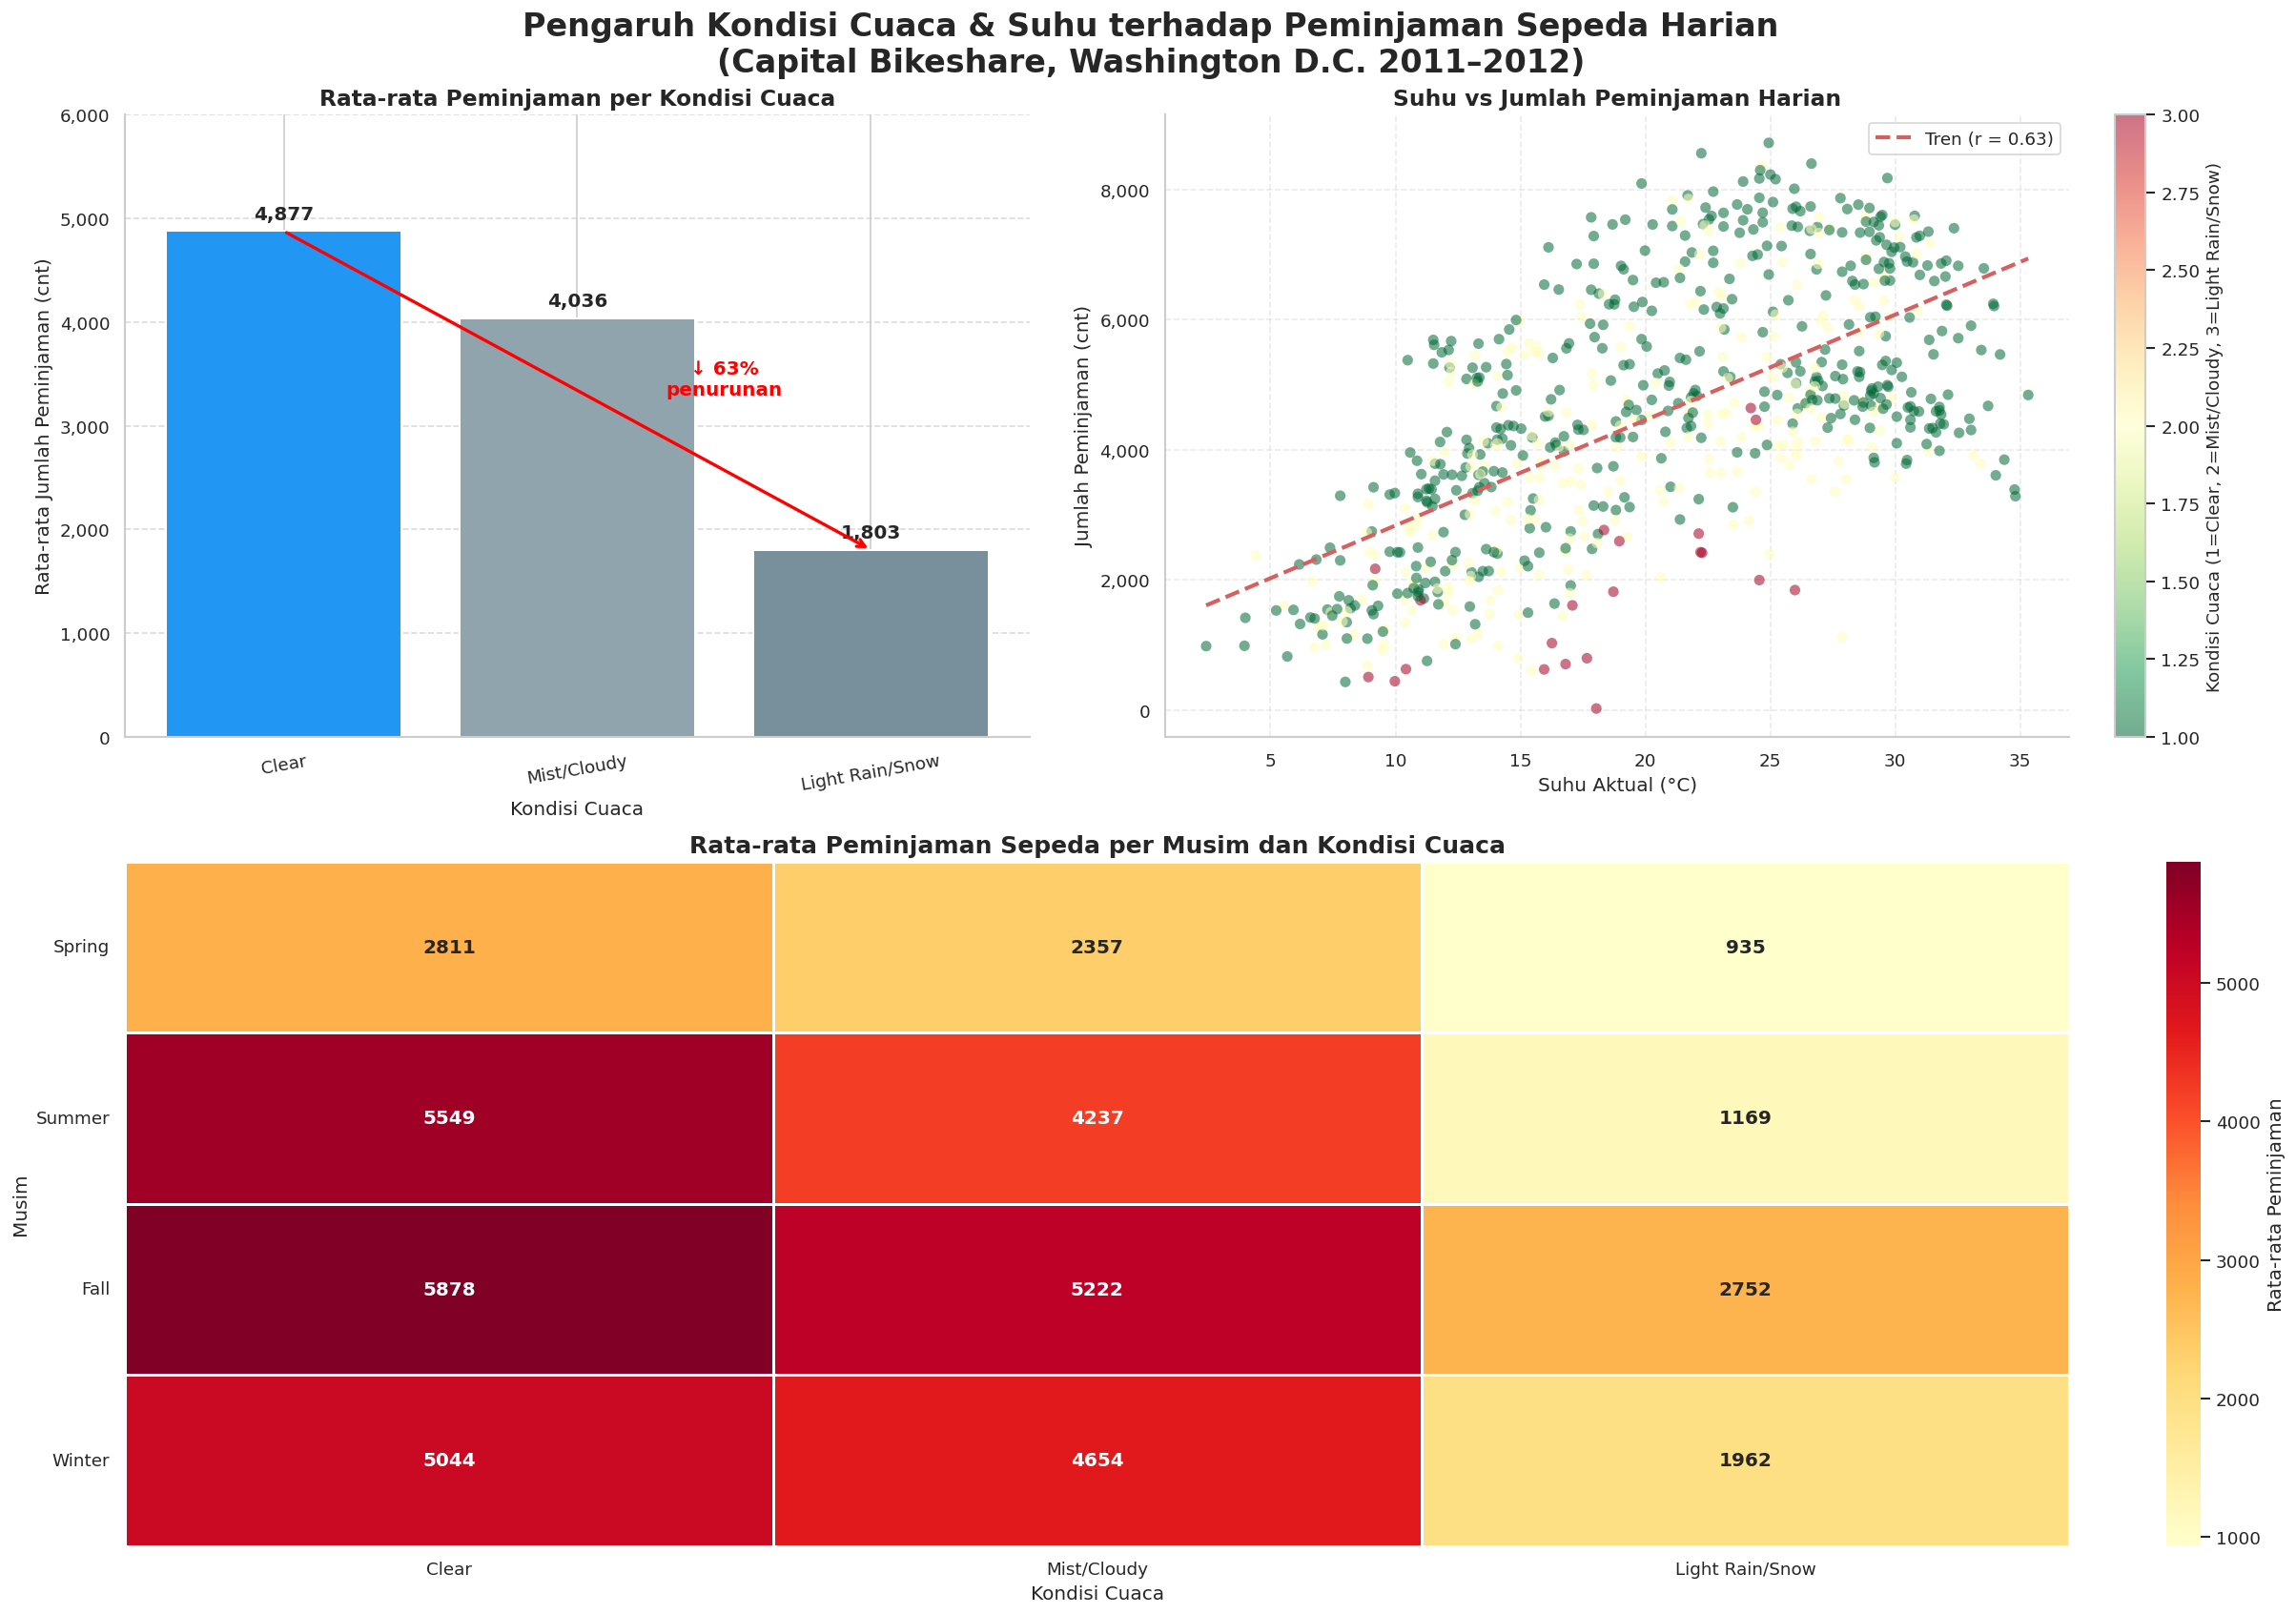

In [ ]:
# Visualisasi Pertanyaan 1: Pengaruh kondisi cuaca dan suhu terhadap peminjaman sepeda harian

fig = plt.figure(figsize=(20, 14), dpi=120, constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.1])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

fig.suptitle(
    'Pengaruh Kondisi Cuaca & Suhu terhadap Peminjaman Sepeda Harian\n'
    '(Capital Bikeshare, Washington D.C. 2011–2012)',
    fontsize=20,
    fontweight='bold'
)

# Plot 1: Bar chart rata-rata cnt per kondisi cuaca

weather_order = ['Clear', 'Mist/Cloudy', 'Light Rain/Snow']
weather_colors = ['#2196F3', '#90A4AE', '#78909C']

weather_data = (
    day_df.groupby('weather_label')['cnt']
    .mean()
    .reindex(weather_order)
)

bars = ax1.bar(
    weather_data.index,
    weather_data.values,
    color=weather_colors,
    edgecolor='white',
    linewidth=1.2
)

for bar, val in zip(bars, weather_data.values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f'{val:,.0f}',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

ax1.set_title(
    'Rata-rata Peminjaman per Kondisi Cuaca',
    fontsize=14,
    fontweight='bold'
)

ax1.set_xlabel('Kondisi Cuaca', fontsize=12)
ax1.set_ylabel('Rata-rata Jumlah Peminjaman (cnt)', fontsize=12)
ax1.tick_params(axis='x', rotation=10, labelsize=11)
ax1.tick_params(axis='y', labelsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.set_ylim(0, 6000)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.spines[['top', 'right']].set_visible(False)

# Annotation penurunan dari Clear ke Light Rain/Snow
pct_drop = (
    (weather_data['Clear'] - weather_data['Light Rain/Snow'])
    / weather_data['Clear'] * 100
)

ax1.annotate(
    '',
    xy=(2, weather_data['Light Rain/Snow']),
    xytext=(0, weather_data['Clear']),
    arrowprops=dict(arrowstyle='->', color='red', lw=2)
)

ax1.text(
    1.5,
    3300,
    f'↓ {pct_drop:.0f}%\npenurunan',
    color='red',
    ha='center',
    fontsize=12,
    fontweight='bold'
)


# Plot 2: Scatter plot suhu vs cnt

sc = ax2.scatter(
    day_df['temp_celsius'],
    day_df['cnt'],
    c=day_df['weathersit'],
    cmap='RdYlGn_r',
    alpha=0.55,
    s=45,
    edgecolors='none'
)

# Trendline
z = np.polyfit(day_df['temp_celsius'], day_df['cnt'], 1)
p = np.poly1d(z)

x_line = np.linspace(
    day_df['temp_celsius'].min(),
    day_df['temp_celsius'].max(),
    100
)

corr_temp_cnt = day_df['temp_celsius'].corr(day_df['cnt'])

ax2.plot(
    x_line,
    p(x_line),
    'r--',
    linewidth=2.5,
    label=f'Tren (r = {corr_temp_cnt:.2f})'
)

cbar = plt.colorbar(sc, ax=ax2)
cbar.set_label('Kondisi Cuaca (1=Clear, 2=Mist/Cloudy, 3=Light Rain/Snow)', fontsize=11)

ax2.set_title(
    'Suhu vs Jumlah Peminjaman Harian',
    fontsize=14,
    fontweight='bold'
)

ax2.set_xlabel('Suhu Aktual (°C)', fontsize=12)
ax2.set_ylabel('Jumlah Peminjaman (cnt)', fontsize=12)
ax2.tick_params(axis='both', labelsize=11)
ax2.legend(fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.grid(linestyle='--', alpha=0.4)
ax2.spines[['top', 'right']].set_visible(False)


# Plot 3: Heatmap rata-rata cnt per musim dan cuaca

season_weather = (
    day_df.groupby(['season_label', 'weather_label'])['cnt']
    .mean()
    .unstack(fill_value=0)
)

season_order_hm = ['Spring', 'Summer', 'Fall', 'Winter']
weather_order_hm = ['Clear', 'Mist/Cloudy', 'Light Rain/Snow']

season_weather = season_weather.reindex(
    index=season_order_hm,
    columns=weather_order_hm
)

sns.heatmap(
    season_weather,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    ax=ax3,
    linewidths=0.8,
    linecolor='white',
    annot_kws={'size': 12, 'weight': 'bold'},
    cbar_kws={'label': 'Rata-rata Peminjaman'}
)

ax3.set_title(
    'Rata-rata Peminjaman Sepeda per Musim dan Kondisi Cuaca',
    fontsize=15,
    fontweight='bold'
)

ax3.set_xlabel('Kondisi Cuaca', fontsize=12)
ax3.set_ylabel('Musim', fontsize=12)
ax3.tick_params(axis='x', rotation=0, labelsize=11)
ax3.tick_params(axis='y', rotation=0, labelsize=11)

# Simpan gambar
plt.savefig('viz_pertanyaan1.png', bbox_inches='tight', dpi=200)
plt.show()

In [ ]:
# =====================================================
# Insight numerik pendukung Pertanyaan 1
# =====================================================

# 1. Ambil hasil dari EDA sebelumnya

clear_avg = weather_avg.loc[
    weather_avg['Kondisi Cuaca'] == 'Clear',
    'Rata-rata Peminjaman'
].iloc[0]

mist_avg = weather_avg.loc[
    weather_avg['Kondisi Cuaca'] == 'Mist/Cloudy',
    'Rata-rata Peminjaman'
].iloc[0]

rain_avg = weather_avg.loc[
    weather_avg['Kondisi Cuaca'] == 'Light Rain/Snow',
    'Rata-rata Peminjaman'
].iloc[0]

pct_drop = weather_avg.loc[
    weather_avg['Kondisi Cuaca'] == 'Light Rain/Snow',
    'Penurunan vs Clear (%)'
].iloc[0]

corr_temp_cnt = corr_matrix.loc['temp_celsius', 'cnt']


# 2. Tabel suhu rata-rata dan peminjaman per bulan

monthly_temp_summary = (
    day_df.groupby(['mnth', 'month_label'])
    .agg({
        'temp_celsius': 'mean',
        'cnt': 'mean',
        'season_label': lambda x: x.mode()[0]
    })
    .round(1)
    .reset_index()
    .sort_values('mnth')
)

monthly_temp_summary.columns = [
    'Nomor Bulan',
    'Bulan',
    'Rata-rata Suhu (°C)',
    'Rata-rata Peminjaman',
    'Musim'
]


# 3. Kombinasi musim-cuaca tertinggi dan terendah

season_weather_summary = (
    day_df.groupby(['season_label', 'weather_label'])
    .agg({
        'temp_celsius': 'mean',
        'cnt': 'mean'
    })
    .round(1)
    .reset_index()
)

season_weather_summary.columns = [
    'Musim',
    'Kondisi Cuaca',
    'Rata-rata Suhu (°C)',
    'Rata-rata Peminjaman'
]

highest_combo = season_weather_summary.loc[
    season_weather_summary['Rata-rata Peminjaman'].idxmax()
]

lowest_combo = season_weather_summary.loc[
    season_weather_summary['Rata-rata Peminjaman'].idxmin()
]

combo_summary = pd.DataFrame([
    {
        'Kategori': 'Tertinggi',
        'Musim': highest_combo['Musim'],
        'Kondisi Cuaca': highest_combo['Kondisi Cuaca'],
        'Rata-rata Suhu (°C)': highest_combo['Rata-rata Suhu (°C)'],
        'Rata-rata Peminjaman': highest_combo['Rata-rata Peminjaman']
    },
    {
        'Kategori': 'Terendah',
        'Musim': lowest_combo['Musim'],
        'Kondisi Cuaca': lowest_combo['Kondisi Cuaca'],
        'Rata-rata Suhu (°C)': lowest_combo['Rata-rata Suhu (°C)'],
        'Rata-rata Peminjaman': lowest_combo['Rata-rata Peminjaman']
    }
])


# 4. Binning suhu

day_df['temp_range'] = pd.cut(
    day_df['temp_celsius'],
    bins=[0, 10, 20, 30, 40],
    labels=['0-10°C', '10-20°C', '20-30°C', '30-40°C'],
    include_lowest=True
)

temp_range_summary = (
    day_df.groupby('temp_range', observed=False)['cnt']
    .agg(['mean', 'median', 'min', 'max', 'count'])
    .round(0)
    .reset_index()
)

temp_range_summary.columns = [
    'Rentang Suhu',
    'Rata-rata Peminjaman',
    'Median',
    'Minimum',
    'Maksimum',
    'Jumlah Data'
]

best_temp_range = temp_range_summary.loc[
    temp_range_summary['Rata-rata Peminjaman'].idxmax()
]


# 5. Output Ringkasan

print('=== Ringkasan Insight Pertanyaan 1 ===\n')

print('Rata-rata peminjaman per kondisi cuaca:')
display(
    weather_avg[
        ['Kondisi Cuaca', 'Rata-rata Peminjaman', 'Selisih dari Clear', 'Penurunan vs Clear (%)']
    ]
    .style
    .hide(axis='index')
    .format({
        'Rata-rata Peminjaman': '{:.0f}',
        'Selisih dari Clear': '{:.0f}',
        'Penurunan vs Clear (%)': '{:.2f}%'
    })
)

print('\nRata-rata suhu dan peminjaman per bulan:')
display(
    monthly_temp_summary[
        ['Bulan', 'Musim', 'Rata-rata Suhu (°C)', 'Rata-rata Peminjaman']
    ]
    .style
    .hide(axis='index')
    .format({
        'Rata-rata Suhu (°C)': '{:.1f}',
        'Rata-rata Peminjaman': '{:.0f}'
    })
)

print('\nKombinasi musim-cuaca dengan rata-rata peminjaman tertinggi dan terendah:')
display(
    combo_summary.style
    .hide(axis='index')
    .format({
        'Rata-rata Suhu (°C)': '{:.1f}',
        'Rata-rata Peminjaman': '{:.0f}'
    })
)

print('\nRata-rata peminjaman berdasarkan rentang suhu:')
display(
    temp_range_summary.style
    .hide(axis='index')
    .format({
        'Rata-rata Peminjaman': '{:.0f}',
        'Median': '{:.0f}',
        'Minimum': '{:.0f}',
        'Maksimum': '{:.0f}',
        'Jumlah Data': '{:.0f}'
    })
)

print(f'\nPenurunan dari Clear ke Light Rain/Snow: {pct_drop:.2f}%')
print(f'Korelasi suhu dengan cnt: {corr_temp_cnt:.2f}')
print(
    f'Rentang suhu dengan rata-rata peminjaman tertinggi: '
    f'{best_temp_range["Rentang Suhu"]} '
    f'({best_temp_range["Rata-rata Peminjaman"]:.0f}/hari)'
)
print(
    f'Kombinasi tertinggi: {highest_combo["Musim"]} + {highest_combo["Kondisi Cuaca"]} '
    f'= {highest_combo["Rata-rata Peminjaman"]:.0f}/hari'
)
print(
    f'Kombinasi terendah: {lowest_combo["Musim"]} + {lowest_combo["Kondisi Cuaca"]} '
    f'= {lowest_combo["Rata-rata Peminjaman"]:.0f}/hari'
)

=== Ringkasan Insight Pertanyaan 1 ===

Rata-rata peminjaman per kondisi cuaca:


Kondisi Cuaca,Rata-rata Peminjaman,Selisih dari Clear,Penurunan vs Clear (%)
Clear,4877,0,0.00%
Mist/Cloudy,4036,841,17.24%
Light Rain/Snow,1803,3074,63.02%



Rata-rata suhu dan peminjaman per bulan:


Bulan,Musim,Rata-rata Suhu (°C),Rata-rata Peminjaman
Jan,Spring,9.7,2176
Feb,Spring,12.3,2655
Mar,Spring,16.0,3692
Apr,Summer,19.3,4485
May,Summer,24.4,5350
Jun,Summer,28.0,5772
Jul,Fall,31.0,5564
Aug,Fall,29.1,5664
Sep,Fall,25.3,5766
Oct,Winter,19.9,5199



Kombinasi musim-cuaca dengan rata-rata peminjaman tertinggi dan terendah:


Kategori,Musim,Kondisi Cuaca,Rata-rata Suhu (°C),Rata-rata Peminjaman
Tertinggi,Fall,Clear,29.6,5878
Terendah,Spring,Light Rain/Snow,11.0,935



Rata-rata peminjaman berdasarkan rentang suhu:


Rentang Suhu,Rata-rata Peminjaman,Median,Minimum,Maksimum,Jumlah Data
0-10°C,1678,1530,431,3422,60
10-20°C,3692,3649,22,8090,299
20-30°C,5662,5354,1115,8714,300
30-40°C,5410,5000,3285,7592,72



Penurunan dari Clear ke Light Rain/Snow: 63.02%
Korelasi suhu dengan cnt: 0.63
Rentang suhu dengan rata-rata peminjaman tertinggi: 20-30°C (5662/hari)
Kombinasi tertinggi: Fall + Clear = 5878/hari
Kombinasi terendah: Spring + Light Rain/Snow = 935/hari


**Insight Pertanyaan 1:**
- **Cuaca adalah faktor penentu utama**: Peminjaman pada cuaca cerah rata-rata **4.877/hari**, turun menjadi **4.036/hari** saat berkabut, dan anjlok ke **1.803/hari** saat hujan ringan/salju - penurunan **63%** dari kondisi terbaik.
- **Suhu berkorelasi positif kuat** (r = 0.63) dengan jumlah peminjaman. Suhu nyaman di kisaran 20–30°C menghasilkan jumlah peminjaman tertinggi.
- **Kombinasi musim gugur + cuaca cerah** adalah kondisi optimal, menghasilkan rata-rata peminjaman tertinggi (5878/hari).
- Musim semi dengan cuaca hujan mencatatkan peminjaman terendah(935/hari), yang konsisten dengan suhu lebih rendah di awal tahun.

### Pertanyaan 2: Pola Jam Puncak Peminjaman pada Hari Kerja vs Hari Libur

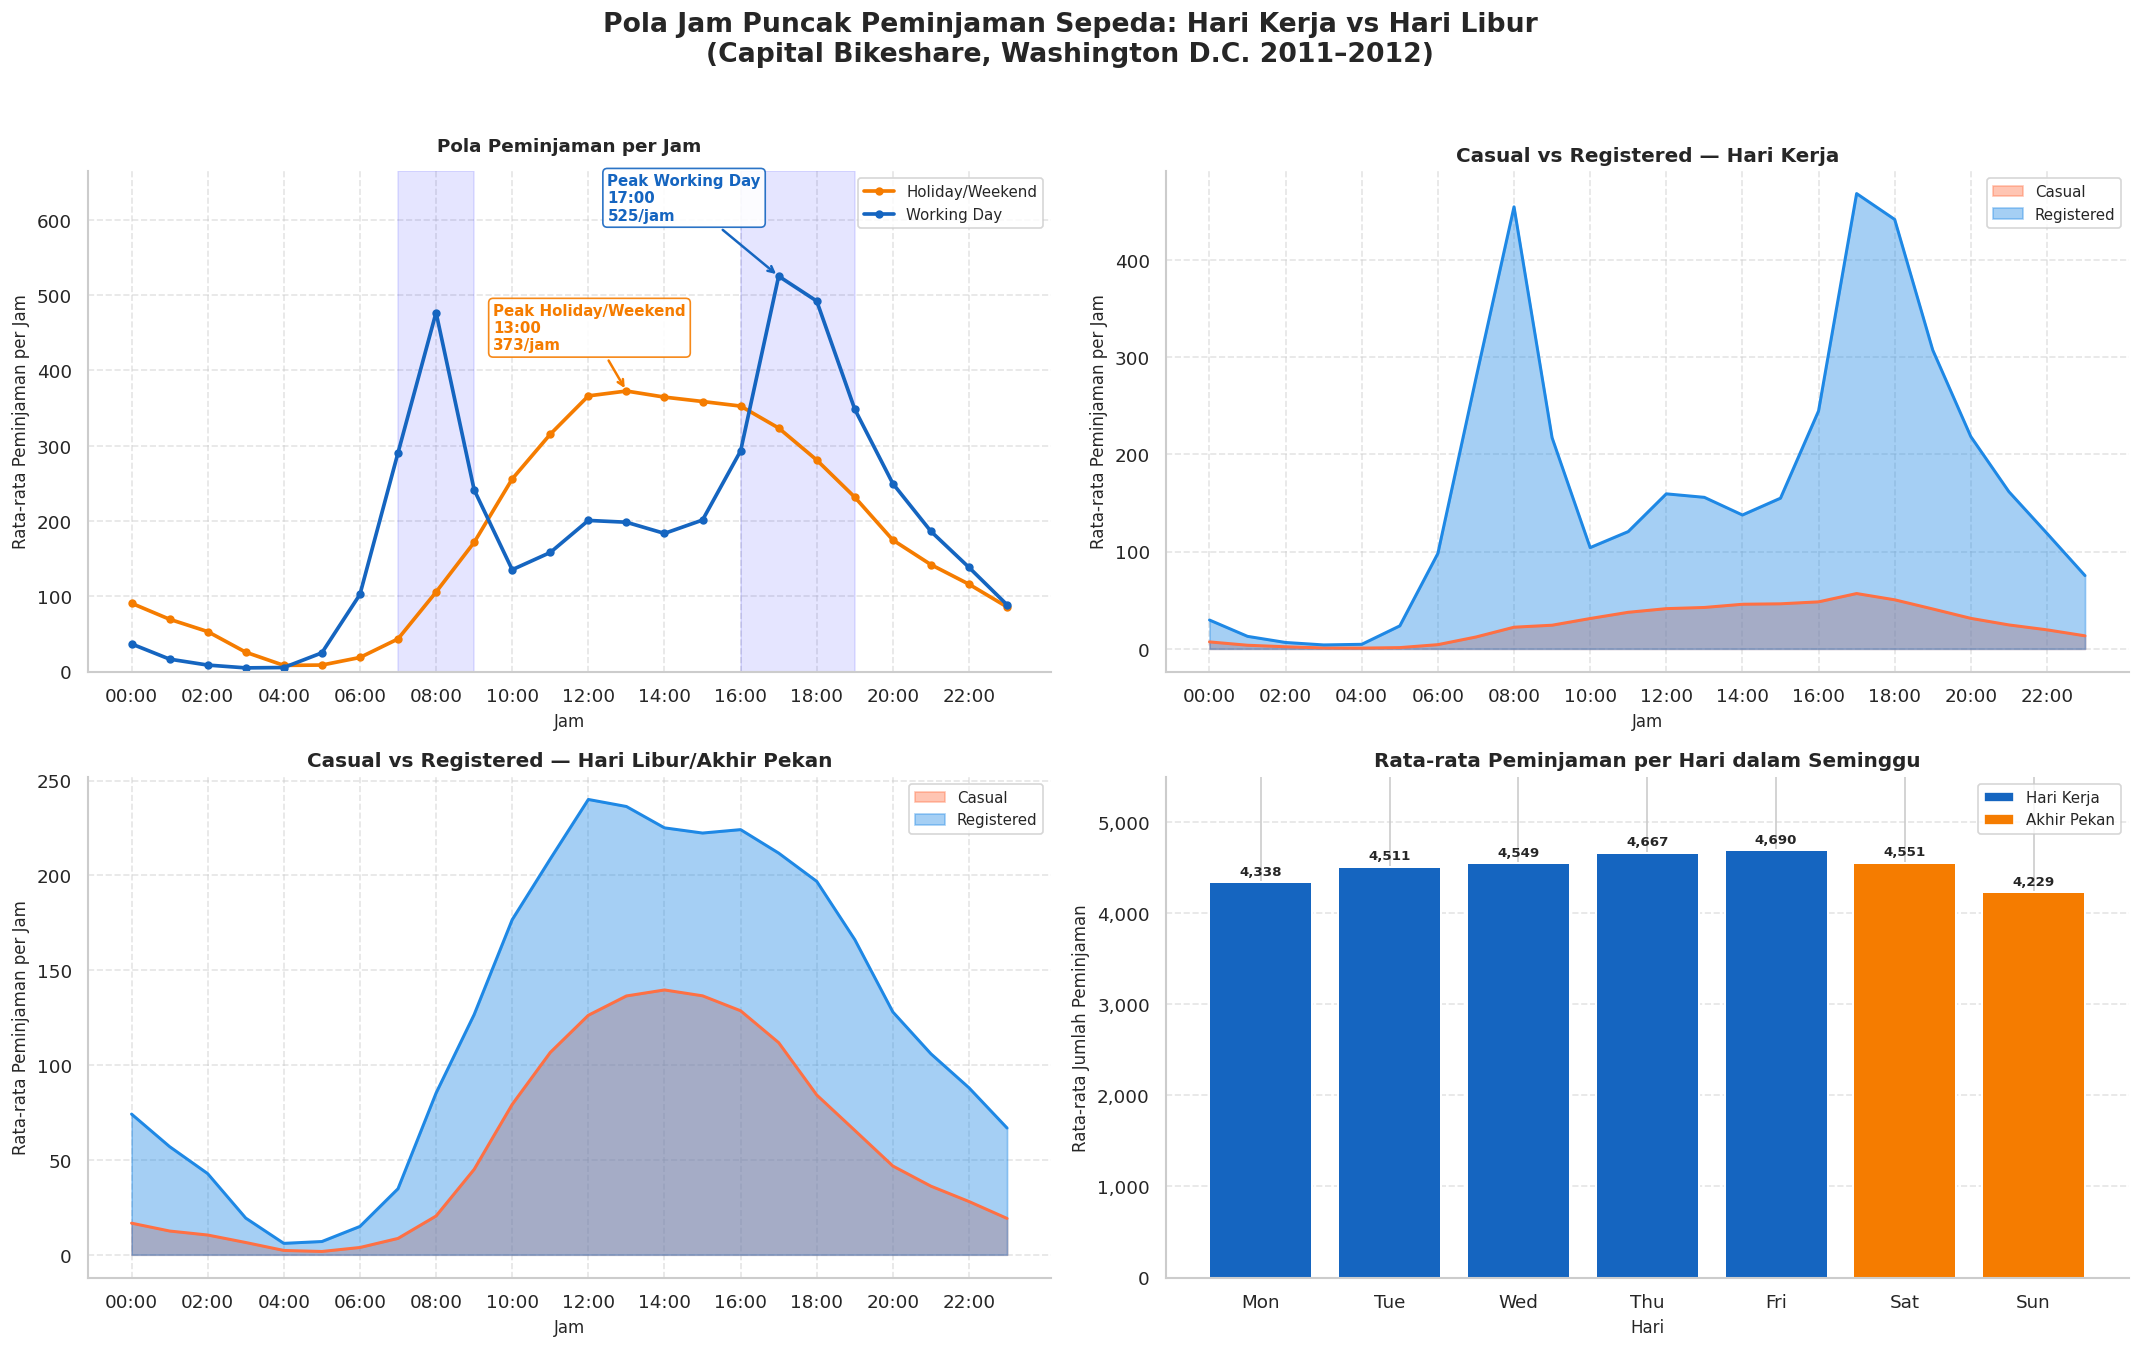

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 11))
fig.suptitle(
    'Pola Jam Puncak Peminjaman Sepeda: Hari Kerja vs Hari Libur\n'
    '(Capital Bikeshare, Washington D.C. 2011–2012)',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

# --- Plot 1: Hourly pattern by workingday ---
ax1 = axes[0, 0]
colors_work = {'Working Day': '#1565C0', 'Holiday/Weekend': '#F57C00'}

for label, grp in hour_df.groupby('workingday_label'):
    avg = grp.groupby('hr')['cnt'].mean()
    ax1.plot(
        avg.index, avg.values,
        marker='o', markersize=4,
        label=label, color=colors_work[label],
        linewidth=2.2
    )

# Data peak
wd = hour_df[hour_df['workingday'] == 1].groupby('hr')['cnt'].mean()
hw = hour_df[hour_df['workingday'] == 0].groupby('hr')['cnt'].mean()

# Tambahkan headroom biar anotasi muat
ymax = max(wd.max(), hw.max())
ax1.set_ylim(0, ymax + 140)

# Working day annotation
ax1.annotate(
    f'Peak Working Day\n{wd.idxmax():02d}:00\n{wd.max():.0f}/jam',
    xy=(wd.idxmax(), wd.max()),
    xytext=(wd.idxmax() - 4.5, wd.max() + 75),
    arrowprops=dict(arrowstyle='->', color='#1565C0', lw=1.5),
    fontsize=9,
    color='#1565C0',
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#1565C0', alpha=0.9)
)

# Holiday/weekend annotation
ax1.annotate(
    f'Peak Holiday/Weekend\n{hw.idxmax():02d}:00\n{hw.max():.0f}/jam',
    xy=(hw.idxmax(), hw.max()),
    xytext=(hw.idxmax() - 3.5, hw.max() + 55),
    arrowprops=dict(arrowstyle='->', color='#F57C00', lw=1.5),
    fontsize=9,
    color='#F57C00',
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#F57C00', alpha=0.9)
)

ax1.set_title('Pola Peminjaman per Jam', fontsize=11, fontweight='bold', pad=12)
ax1.set_xlabel('Jam', fontsize=10)
ax1.set_ylabel('Rata-rata Peminjaman per Jam', fontsize=10)

# Format sumbu x jadi jam
hour_ticks = list(range(0, 24, 2))
hour_labels = [f'{h:02d}:00' for h in hour_ticks]
ax1.set_xticks(hour_ticks)
ax1.set_xticklabels(hour_labels)

ax1.legend(fontsize=9)
ax1.grid(linestyle='--', alpha=0.5)
ax1.spines[['top', 'right']].set_visible(False)

# Shade peak zones
ax1.axvspan(7, 9, alpha=0.1, color='blue', label='_nolegend_')
ax1.axvspan(16, 19, alpha=0.1, color='blue', label='_nolegend_')

# --- Plot 2: Casual vs Registered pada hari kerja ---

ax2 = axes[0, 1]

wday = hour_df[hour_df['workingday'] == 1].groupby('hr')[['casual', 'registered']].mean()

ax2.fill_between(wday.index, wday['casual'], alpha=0.4, color='#FF7043', label='Casual')
ax2.fill_between(wday.index, wday['registered'], alpha=0.4, color='#1E88E5', label='Registered')
ax2.plot(wday.index, wday['casual'], color='#FF7043', linewidth=1.8)
ax2.plot(wday.index, wday['registered'], color='#1E88E5', linewidth=1.8)

ax2.set_title('Casual vs Registered — Hari Kerja', fontsize=12, fontweight='bold')
ax2.set_xlabel('Jam', fontsize=10)
ax2.set_ylabel('Rata-rata Peminjaman per Jam', fontsize=10)
ax2.set_xticks(range(0, 24, 2))
ax2.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)])
ax2.legend(fontsize=9)
ax2.grid(linestyle='--', alpha=0.5)
ax2.spines[['top', 'right']].set_visible(False)


# --- Plot 3: Casual vs Registered pada hari libur/akhir pekan ---

ax3 = axes[1, 0]

hday = hour_df[hour_df['workingday'] == 0].groupby('hr')[['casual', 'registered']].mean()

ax3.fill_between(hday.index, hday['casual'], alpha=0.4, color='#FF7043', label='Casual')
ax3.fill_between(hday.index, hday['registered'], alpha=0.4, color='#1E88E5', label='Registered')
ax3.plot(hday.index, hday['casual'], color='#FF7043', linewidth=1.8)
ax3.plot(hday.index, hday['registered'], color='#1E88E5', linewidth=1.8)

ax3.set_title('Casual vs Registered — Hari Libur/Akhir Pekan', fontsize=12, fontweight='bold')
ax3.set_xlabel('Jam', fontsize=10)
ax3.set_ylabel('Rata-rata Peminjaman per Jam', fontsize=10)
ax3.set_xticks(range(0, 24, 2))
ax3.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)])
ax3.legend(fontsize=9)
ax3.grid(linestyle='--', alpha=0.5)
ax3.spines[['top', 'right']].set_visible(False)


# --- Plot 4: Rata-rata peminjaman per hari dalam seminggu ---

ax4 = axes[1, 1]

weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
weekday_colors = ['#1565C0'] * 5 + ['#F57C00'] * 2

wk_avg = day_df.groupby('weekday_label')['cnt'].mean().reindex(weekday_order)

bars = ax4.bar(
    wk_avg.index,
    wk_avg.values,
    color=weekday_colors,
    edgecolor='white',
    linewidth=1.2
)

for bar, val in zip(bars, wk_avg.values):
    ax4.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f'{val:,.0f}',
        ha='center',
        va='bottom',
        fontsize=8,
        fontweight='bold'
    )

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1565C0', label='Hari Kerja'),
    Patch(facecolor='#F57C00', label='Akhir Pekan')
]

ax4.set_title('Rata-rata Peminjaman per Hari dalam Seminggu', fontsize=12, fontweight='bold')
ax4.set_xlabel('Hari', fontsize=10)
ax4.set_ylabel('Rata-rata Jumlah Peminjaman', fontsize=10)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax4.legend(handles=legend_elements, fontsize=9)
ax4.set_ylim(0, 5500)
ax4.grid(axis='y', linestyle='--', alpha=0.5)
ax4.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('viz_pertanyaan2.png', bbox_inches='tight', dpi=200)
plt.show()

**Insight Pertanyaan 2:**
- **Hari kerja** menunjukkan pola bimodal tajam: puncak pertama pada **jam 08:00** (477/jam) dan puncak kedua lebih tinggi pada **jam 17:00** (595/jam), yang mencerminkan perjalanan komuter.
- **Hari libur/akhir pekan** memiliki pola unimodal yang lebih landai, puncak di **jam 12:00-13:00** (~367/jam).
- Pengguna **registered** mendominasi hari kerja, terutama di jam-jam komuter. Pengguna **casual** memiliki proporsi lebih tinggi di akhir pekan.
- Secara rata-rata harian, **Jumat** (4.690/hari) adalah hari tersibuk, sedangkan **Minggu** (4.229/hari) terendah - meski perbedaannya tidak terlalu besar. 

## Analisis Lanjutan - Clustering Hari Berdasarkan Pola Penggunaan

Pada bagian ini, kita melakukan **manual clustering (binning)** untuk mengelompokkan hari-hari peminjaman berdasarkan jumlah penggunaan. Tujuannya adalah memahami distribusi dan karakteristik setiap kelompok penggunaan, yang berguna untuk perencanaan armada dan strategi operasional.

In [ ]:
# Profil per usage_category
cluster_profile = day_df.groupby('usage_category_day', observed=True).agg(
    jumlah_hari=('cnt', 'count'),
    avg_cnt=('cnt', 'mean'),
    avg_temp_celsius=('temp_celsius', 'mean'),
    avg_hum_percent=('hum_percent', 'mean'),
    avg_windspeed=('windspeed_kmh', 'mean'),
    pct_clear_weather=('weathersit', lambda x: (x == 1).mean() * 100),
    pct_workingday=('workingday', 'mean')
).reset_index()

cluster_profile.columns = ['Kategori Penggunaan', 'Jumlah Hari', 'Avg Peminjaman',
                           'Avg Suhu (°C)', 'Avg Kelembapan (%)', 'Avg Kec. Angin (km/h)',
                           '% Cuaca Cerah', '% Hari Kerja']
cluster_profile = cluster_profile.round(1)
print('Profil Cluster Berdasarkan Kategori Penggunaan:')
print(cluster_profile.to_string(index=False))

Profil Cluster Berdasarkan Kategori Penggunaan:
Kategori Penggunaan  Jumlah Hari  Avg Peminjaman  Avg Suhu (°C)  Avg Kelembapan (%)  Avg Kec. Angin (km/h)  % Cuaca Cerah  % Hari Kerja
         Low (0-2K)           98          1394.8           11.1                63.1                   15.0           44.9           0.6
     Medium (2K-4K)          181          3108.0           16.5                64.0                   13.5           52.5           0.7
       High (4K-6K)          272          4862.6           22.7                63.2                   12.5           67.6           0.7
    Very High (6K+)          180          7060.1           25.6                60.8                   11.3           77.8           0.7


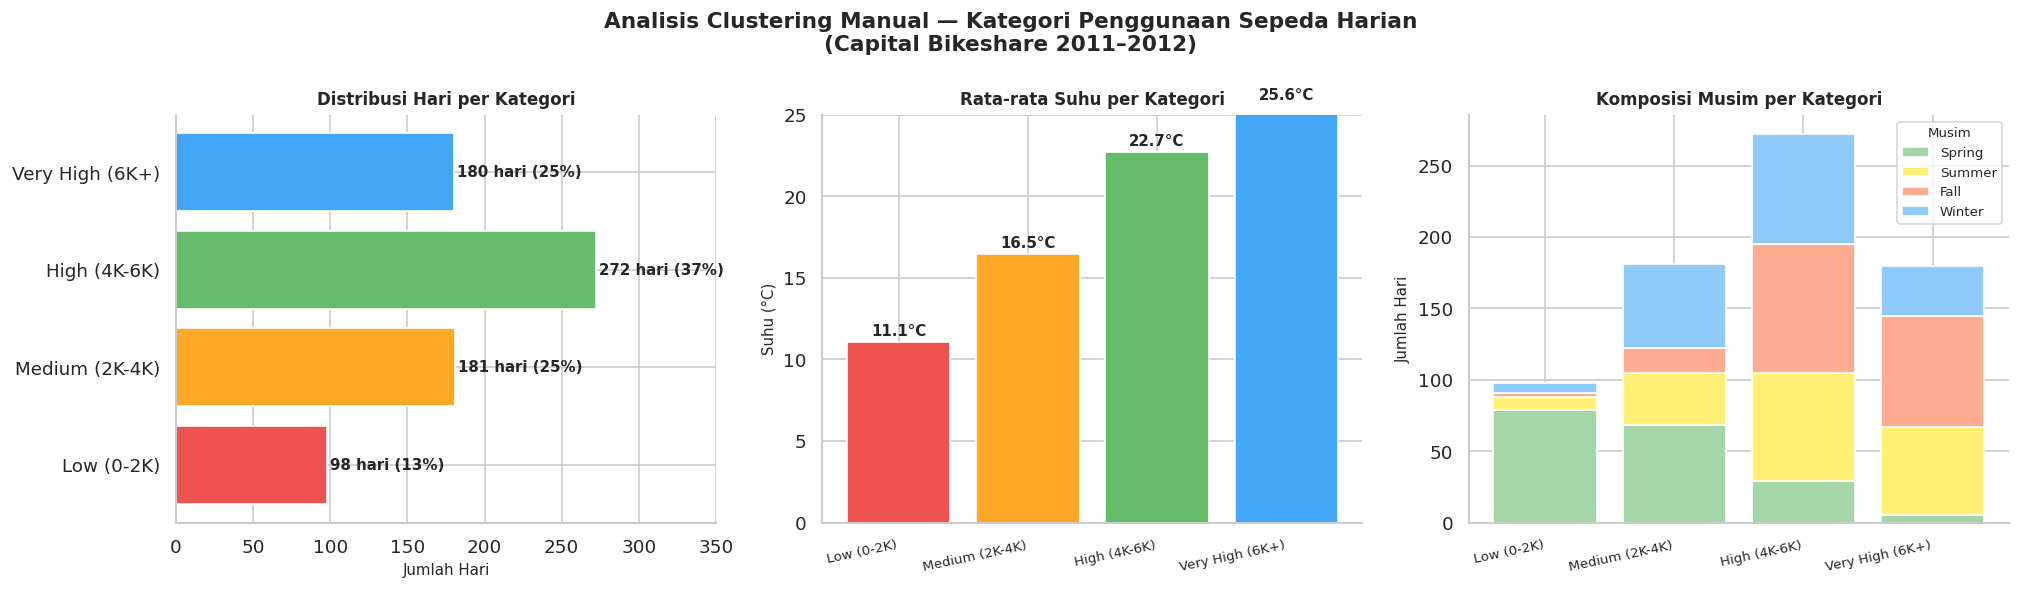

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Analisis Clustering Manual — Kategori Penggunaan Sepeda Harian\n(Capital Bikeshare 2011–2012)',
             fontsize=13, fontweight='bold')

cat_order = ['Low (0-2K)', 'Medium (2K-4K)', 'High (4K-6K)', 'Very High (6K+)']
cat_colors = ['#EF5350', '#FFA726', '#66BB6A', '#42A5F5']

# Plot 1: Jumlah hari per kategori
ax1 = axes[0]
counts = day_df['usage_category_day'].value_counts().reindex(cat_order)
bars = ax1.barh(cat_order, counts.values, color=cat_colors, edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             f'{val} hari ({val/len(day_df)*100:.0f}%)', va='center', fontsize=9, fontweight='bold')
ax1.set_title('Distribusi Hari per Kategori', fontsize=10, fontweight='bold')
ax1.set_xlabel('Jumlah Hari', fontsize=9)
ax1.set_xlim(0, 350)
ax1.spines[['top', 'right']].set_visible(False)

# Plot 2: Rata-rata suhu per kategori
ax2 = axes[1]
temp_avg = day_df.groupby('usage_category_day', observed=True)['temp_celsius'].mean().reindex(cat_order)
bars2 = ax2.bar(cat_order, temp_avg.values, color=cat_colors, edgecolor='white')
for bar, val in zip(bars2, temp_avg.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}°C', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_title('Rata-rata Suhu per Kategori', fontsize=10, fontweight='bold')
ax2.set_ylabel('Suhu (°C)', fontsize=9)
ax2.set_xticklabels(cat_order, rotation=12, ha='right', fontsize=8)
ax2.set_ylim(0, 25)
ax2.spines[['top', 'right']].set_visible(False)

# Plot 3: Distribusi musim per cluster (stacked bar)
ax3 = axes[2]
season_cluster = day_df.groupby(['usage_category_day', 'season_label'], observed=True).size().unstack(fill_value=0)
season_cluster = season_cluster.reindex(cat_order)
season_cols_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_colors_map = {'Spring': '#A5D6A7', 'Summer': '#FFF176', 'Fall': '#FFAB91', 'Winter': '#90CAF9'}
bottom = np.zeros(len(cat_order))
for s in season_cols_order:
    if s in season_cluster.columns:
        vals = season_cluster[s].values
        ax3.bar(cat_order, vals, bottom=bottom, label=s, color=season_colors_map[s], edgecolor='white')
        bottom += vals
ax3.set_title('Komposisi Musim per Kategori', fontsize=10, fontweight='bold')
ax3.set_ylabel('Jumlah Hari', fontsize=9)
ax3.set_xticklabels(cat_order, rotation=12, ha='right', fontsize=8)
ax3.legend(title='Musim', fontsize=8, title_fontsize=8)
ax3.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('viz_clustering.png', bbox_inches='tight', dpi=120)
plt.show()

**Insight Analisis Lanjutan (Clustering):**
- **37% hari** masuk kategori **High (4K-6K)**, menjadikannya kategori paling umum.
- Kategori **Very High (6K+)** memiliki rata-rata suhu **25.6°C** - lebih hangat dari kategori lainnya - dan didominasi oleh hari-hari di musim gugur dan musim panas.
- Kategori **Low (0-2K)** hampir seluruhnya terjadi di musim semi dengan suhu rendah (11.1°C), mengonfirmasi hubungan kuat antara suhu dan volume peminjaman.
- Clustering ini dapat digunakan sebagai dasar pengaturan jumlah sepeda yang tersedia: lebih banyak stok pada prakiraan suhu tinggi + cuaca cerah di musim gugur/panas.

## Conclusion & Recommendation

### Kesimpulan

**Conclusion Pertanyaan 1 - Pengaruh Cuaca & Suhu:**

- Kondisi cuaca dan suhu terbukti menjadi faktor paling berpengaruh terhadap jumlah peminjaman sepeda harian. Cuaca cerah menghasilkan rata-rata **4.877 peminjaman/hari**, sementara cuaca hujan ringan/salju hanya **1.803 peminjaman/hari** - penurunan sebesar **63%**. Suhu memiliki korelasi positif kuat (r = 0.63) dengan peminjaman: suhu nyaman di 20–30°C mendorong paling banyak aktivitas bersepeda. Musim gugur dengan cuaca cerah adalah kombinasi optimal untuk volume peminjaman tertinggi.

---

**Conclusion Pertanyaan 2 - Pola Jam Puncak:**

- Terdapat perbedaan pola yang sangat jelas antara hari kerja dan hari libur. Pada hari kerja, puncak terjadi di jam 08:00 dan 17:00 (pola bimodal komuter) yang didominasi pengguna *registered*. Pada hari libur, puncak terjadi di siang hari (11:00–14:00) dengan proporsi pengguna *casual* lebih tinggi dari hari kerja. Hal ini menunjukkan dua segmen pengguna yang berbeda: **komuter harian** dan **pesepeda rekreasi**.


### Rekomendasi Action Item

1. **Manajemen Armada Berbasis Cuaca**: Integrasikan data prakiraan cuaca dengan sistem manajemen armada. Pada hari dengan cuaca buruk atau suhu di bawah 10°C, kurangi jumlah sepeda yang dioperasikan di stasiun-stasiun pinggiran dan fokuskan di stasiun pusat kota dengan shelter untuk menekan biaya operasional.

2. **Redistribusi Sepeda Berdasarkan Jam Puncak**:
   - **Hari kerja**: Pastikan stasiun di kawasan perumahan terisi penuh sebelum jam 07:30 dan stasiun di kawasan perkantoran terisi sebelum jam 16:30.
   - **Akhir pekan**: Fokuskan stok di stasiun dekat taman, area rekreasi, dan pusat kota pada jam 10:00–15:00.

3. **Program Loyalitas untuk Pengguna Casual di Akhir Pekan**: Mengingat tingginya proporsi pengguna casual pada akhir pekan, rancang program promosi atau paket membership akhir pekan untuk mengkonversi mereka menjadi pengguna registered (komuter tetap), yang akan meningkatkan pendapatan berulang.

4. **Perencanaan Musiman**: Alokasikan anggaran perawatan armada pada musim dingin dan awal semi (low season) agar unit sepeda dalam kondisi prima saat memasuki musim semi akhir dan musim panas (peak season).